# Flower Classification

In [2]:
import os
import time
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

import tensorflow as tf
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import *
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.optimizers import Adam, SGD
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import *
import seaborn as sns
from PIL import Image

tf.random.set_seed(42)
np.random.seed(42)

# 1. Setup paths

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [6]:
ROOT = "/content/drive/MyDrive/AI and ML/Coursework/Flower Classification"

TRAIN_DIR = os.path.join(ROOT, "Train")
TEST_DIR  = os.path.join(ROOT, "Test")

IMG_SIZE = (128, 128)
BATCH    = 32

CLASSES = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
NUM_CLASSES = len(CLASSES)

print("Classes:", CLASSES)

Classes: ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


# 2. Clean corrupted images (files)


In [7]:
def clean_folder(path):
    removed = 0
    for root, _, files in os.walk(path):
        for f in files:
            fp = os.path.join(root, f)
            try:
                Image.open(fp).verify()
            except:
                os.remove(fp)
                removed += 1
    return removed

print("Removed (train):", clean_folder(TRAIN_DIR))
print("Removed (test) :", clean_folder(TEST_DIR))

Removed (train): 0
Removed (test) : 0


# 3. Data Analysis

In [8]:
# 2a. Count images per class
class_counts = {}
for cls in CLASSES:
    path  = os.path.join(TRAIN_DIR, cls)
    count = len([f for f in os.listdir(path)
                 if f.lower().endswith(('.jpg','.jpeg','.png'))])
    class_counts[cls] = count

total = sum(class_counts.values())
print(f"Total images: {total}\n")
for cls, cnt in class_counts.items():
    print(f"  {cls:>12}: {cnt} images ({cnt/total*100:.1f}%)")

Total images: 4276

         daisy: 756 images (17.7%)
     dandelion: 1044 images (24.4%)
          rose: 776 images (18.1%)
     sunflower: 725 images (17.0%)
         tulip: 975 images (22.8%)


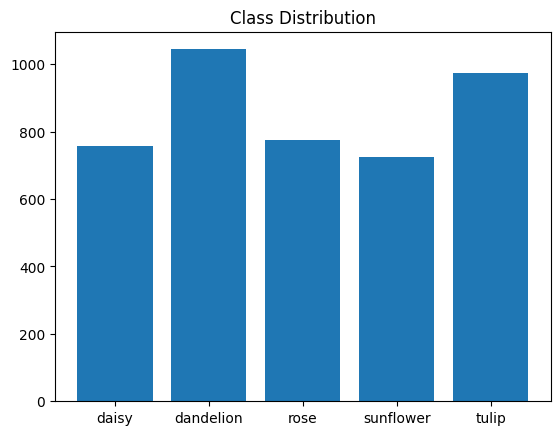

In [9]:
counts = {}
for c in CLASSES:
    counts[c] = len(os.listdir(os.path.join(TRAIN_DIR, c)))

plt.bar(counts.keys(), counts.values())
plt.title("Class Distribution")
plt.show()

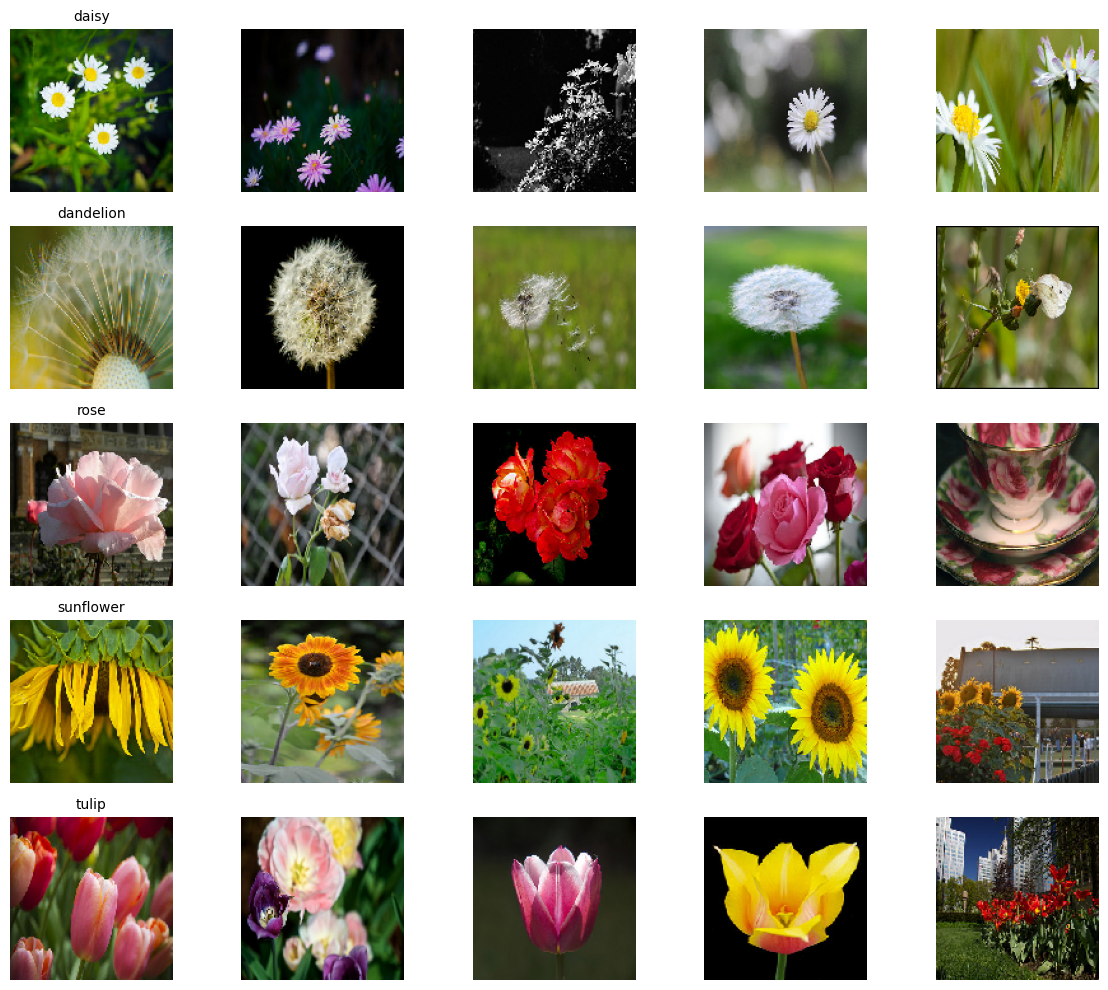

In [10]:
import os
import matplotlib.pyplot as plt
from tensorflow.keras.utils import load_img

# Display 5 images per class
fig, axes = plt.subplots(len(CLASSES), 5, figsize=(12, 10))

for i, cls in enumerate(CLASSES):
    class_path = os.path.join(TRAIN_DIR, cls)
    images = os.listdir(class_path)[:5]  # first 5 images

    for j, img_name in enumerate(images):
        img_path = os.path.join(class_path, img_name)
        img = load_img(img_path, target_size=IMG_SIZE)

        axes[i, j].imshow(img)
        axes[i, j].axis("off")

        if j == 0:
            axes[i, j].set_title(cls, fontsize=10)

plt.tight_layout()
plt.show()

# 4. Data Generators

In [ ]:
# 3a. Data generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(train_gen.class_indices.keys())
print("Train samples :", train_gen.samples)
print("Val   samples :", val_gen.samples)
print("Class indices :", train_gen.class_indices)

Found 3423 images belonging to 5 classes.
Found 854 images belonging to 5 classes.
Train samples : 3423
Val   samples : 854
Class indices : {'daisy': 0, 'dandelion': 1, 'rose': 2, 'sunflower': 3, 'tulip': 4}


# 5. Baseline CNN

In [11]:
# 4a. Build baseline model
def build_baseline_cnn():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same',
               input_shape=(128, 128, 3)),
        MaxPooling2D((2,2)),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        MaxPooling2D((2,2)),

        # Fully connected layers
        Flatten(),
        Dense(256, activation='relu'),
        Dense(128, activation='relu'),
        Dense(64,  activation='relu'),

        # Output — 5 classes
        Dense(5, activation='softmax')
    ], name='Baseline_CNN')
    return model

baseline_model = build_baseline_cnn()
baseline_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
baseline_model.summary()

Model: "Baseline_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
# Re-run generators after cleaning
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

val_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names = list(train_gen.class_indices.keys())
print("Train samples:", train_gen.samples)
print("Val   samples:", val_gen.samples)

Found 3422 images belonging to 5 classes.
Found 854 images belonging to 5 classes.
Train samples: 3422
Val   samples: 854


In [ ]:
# 4b. Train baseline model
callbacks = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

start = time.time()

history_baseline = baseline_model.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=callbacks,
    verbose=1
)

baseline_time = time.time() - start
print(f"\nBaseline training time: {baseline_time:.1f}s  ({baseline_time/60:.1f} min)")

Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 272s 3s/step - accuracy: 0.4316 - loss: 1.3034 - val_accuracy: 0.4438 - val_loss: 1.2262 - learning_rate: 0.0010
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 325s 3s/step - accuracy: 0.5283 - loss: 1.1009 - val_accuracy: 0.5445 - val_loss: 1.1022 - learning_rate: 0.0010
Epoch 3/30
 40/107 ━━━━━━━━━━━━━━━━━━━━ 2:05 2s/step - accuracy: 0.5872 - loss: 0.9873

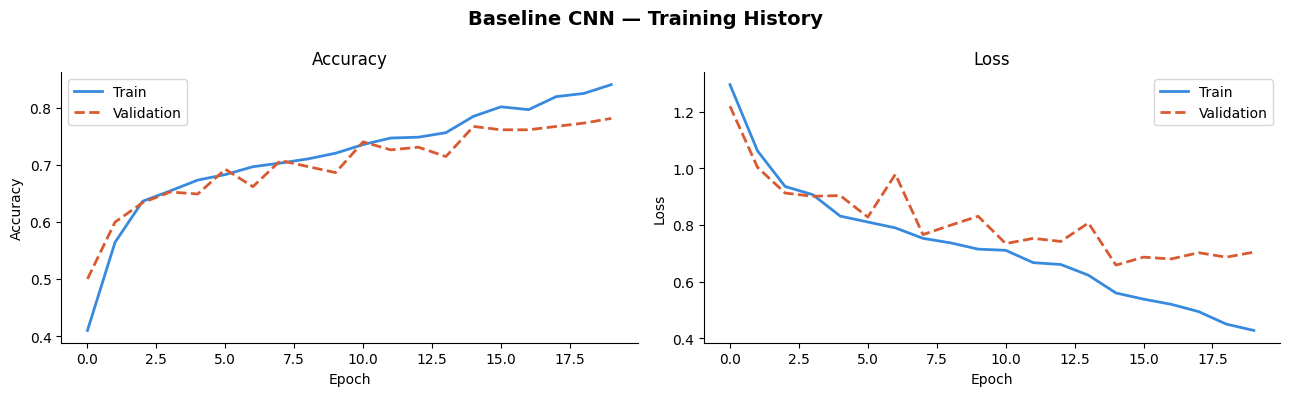

In [ ]:
def plot_history(history, title, save_name):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    ax1.plot(history.history['accuracy'],     label='Train', linewidth=2)
    ax1.plot(history.history['val_accuracy'], label='Validation', linewidth=2, linestyle='--')
    ax1.set_title('Accuracy')
    ax1.set_xlabel('Epoch')
    ax1.set_ylabel('Accuracy')
    ax1.legend()
    ax1.spines[['top','right']].set_visible(False)

    ax2.plot(history.history['loss'],     label='Train', linewidth=2)
    ax2.plot(history.history['val_loss'], label='Validation', linewidth=2, linestyle='--')
    ax2.set_title('Loss')
    ax2.set_xlabel('Epoch')
    ax2.set_ylabel('Loss')
    ax2.legend()
    ax2.spines[['top','right']].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_name, dpi=150)
    plt.show()

plot_history(history_baseline, 'Baseline CNN — Training History', 'baseline_history.png')


── Baseline CNN ──
Accuracy : 0.7670
Precision: 0.7750
Recall   : 0.7670
F1-Score : 0.7682

Classification Report:

              precision    recall  f1-score   support

       daisy       0.86      0.83      0.85       151
   dandelion       0.77      0.83      0.80       208
        rose       0.64      0.76      0.69       155
   sunflower       0.89      0.74      0.81       145
       tulip       0.74      0.67      0.70       195

    accuracy                           0.77       854
   macro avg       0.78      0.77      0.77       854
weighted avg       0.77      0.77      0.77       854



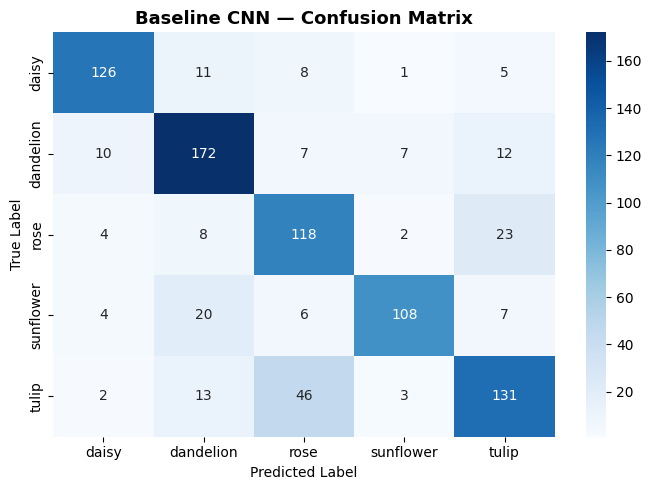

In [ ]:
def evaluate_model(model, generator, name):
    generator.reset()
    y_pred = np.argmax(model.predict(generator, verbose=0), axis=1)
    y_true = generator.classes
    names  = list(generator.class_indices.keys())

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average='weighted', zero_division=0)
    rec  = recall_score(y_true, y_pred, average='weighted', zero_division=0)
    f1   = f1_score(y_true, y_pred, average='weighted', zero_division=0)

    print(f"\n {name}")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-Score : {f1:.4f}")
    print(f"\nClassification Report:\n")
    print(classification_report(y_true, y_pred, target_names=names))

    # Confusion matrix
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=names, yticklabels=names, ax=ax)
    ax.set_title(f'{name} — Confusion Matrix', fontsize=13, fontweight='bold')
    ax.set_ylabel('True Label')
    ax.set_xlabel('Predicted Label')
    plt.tight_layout()
    plt.savefig(f'{name.replace(" ","_")}_confusion.png', dpi=150)
    plt.show()

    return {'accuracy': acc, 'precision': prec, 'recall': rec, 'f1': f1}

baseline_metrics = evaluate_model(baseline_model, val_gen, 'Baseline CNN')

# 6. Deep CNN

In [ ]:
# 5a. Build deeper model
def build_deeper_cnn():
    model = Sequential([
        # Block 1
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.25),

        # Block 3
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),
        Dropout(0.3),

        # Classifier head
        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(5, activation='softmax')
    ], name='Deeper_CNN')
    return model

deeper_model = build_deeper_cnn()
deeper_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
deeper_model.summary()

Model: "Deeper_CNN"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 128, 128, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_8 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 64, 64, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 32, 32, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 512)            │    16,777,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 512)            │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 17,201,189 (65.62 MB)

 Trainable params: 17,199,269 (65.61 MB)

 Non-trainable params: 1,920 (7.50 KB)

In [ ]:
callbacks_deeper = [
    EarlyStopping(monitor='val_loss', patience=7,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

start = time.time()

history_deeper = deeper_model.fit(
    train_gen,
    epochs=40,
    validation_data=val_gen,
    callbacks=callbacks_deeper,
    verbose=1
)

deeper_time = time.time() - start
print(f"\nDeeper model training time: {deeper_time:.1f}s  ({deeper_time/60:.1f} min)")

Epoch 1/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 67s 413ms/step - accuracy: 0.4049 - loss: 1.8001 - val_accuracy: 0.2436 - val_loss: 5.8111 - learning_rate: 0.0010
Epoch 2/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 255ms/step - accuracy: 0.4803 - loss: 1.5136 - val_accuracy: 0.2436 - val_loss: 4.0236 - learning_rate: 0.0010
Epoch 3/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 40s 375ms/step - accuracy: 0.5337 - loss: 1.2925 - val_accuracy: 0.3044 - val_loss: 2.7141 - learning_rate: 0.0010
Epoch 4/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 272ms/step - accuracy: 0.5732 - loss: 1.1586 - val_accuracy: 0.3548 - val_loss: 2.5301 - learning_rate: 0.0010
Epoch 5/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 243ms/step - accuracy: 0.5922 - loss: 1.0402 - val_accuracy: 0.2646 - val_loss: 2.6349 - learning_rate: 0.0010
Epoch 6/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 250ms/step - accuracy: 0.6214 - loss: 0.9975 - val_accuracy: 0.6370 - val_loss: 1.0442 - learning_rate: 0.0010
Epoch 7/40
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 256ms/step - accuracy: 0.6

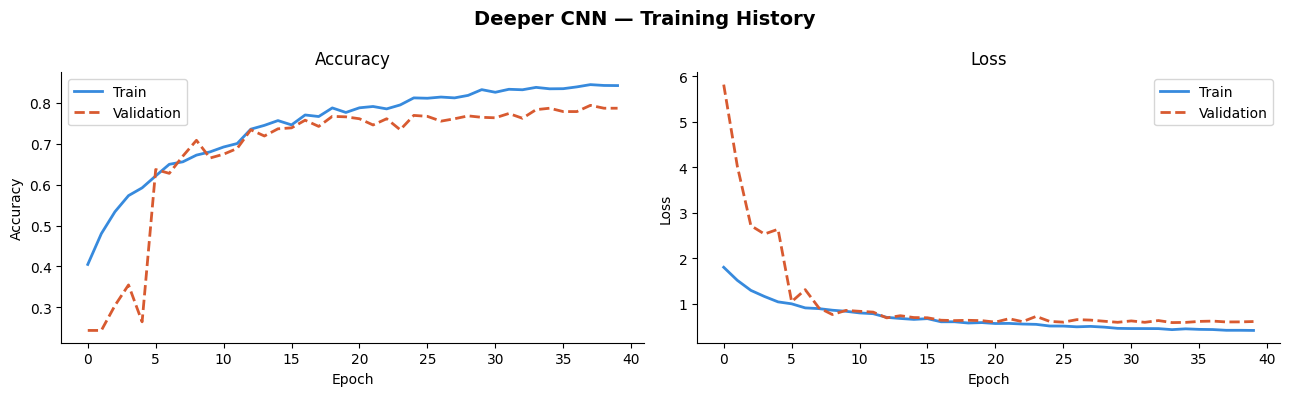

In [ ]:
plot_history(history_deeper, 'Deeper CNN — Training History', 'deeper_history.png')


── Deeper CNN ──
Accuracy : 0.7834
Precision: 0.7892
Recall   : 0.7834
F1-Score : 0.7833

Classification Report:

              precision    recall  f1-score   support

       daisy       0.92      0.79      0.85       151
   dandelion       0.72      0.88      0.79       208
        rose       0.74      0.66      0.70       155
   sunflower       0.80      0.78      0.79       145
       tulip       0.80      0.77      0.79       195

    accuracy                           0.78       854
   macro avg       0.79      0.78      0.78       854
weighted avg       0.79      0.78      0.78       854



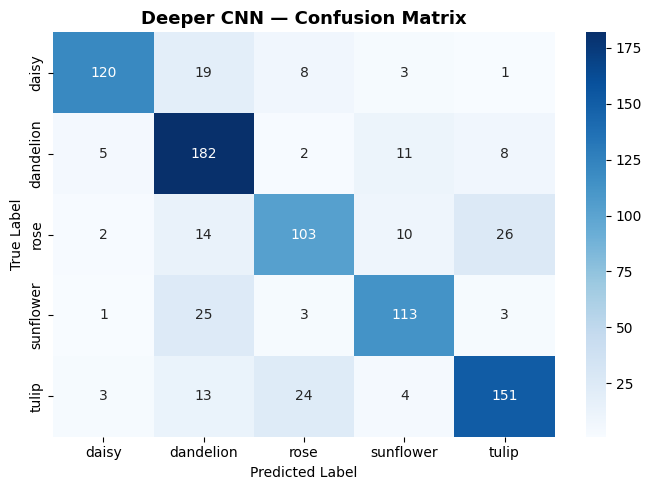

In [ ]:
deeper_metrics = evaluate_model(deeper_model, val_gen, 'Deeper CNN')

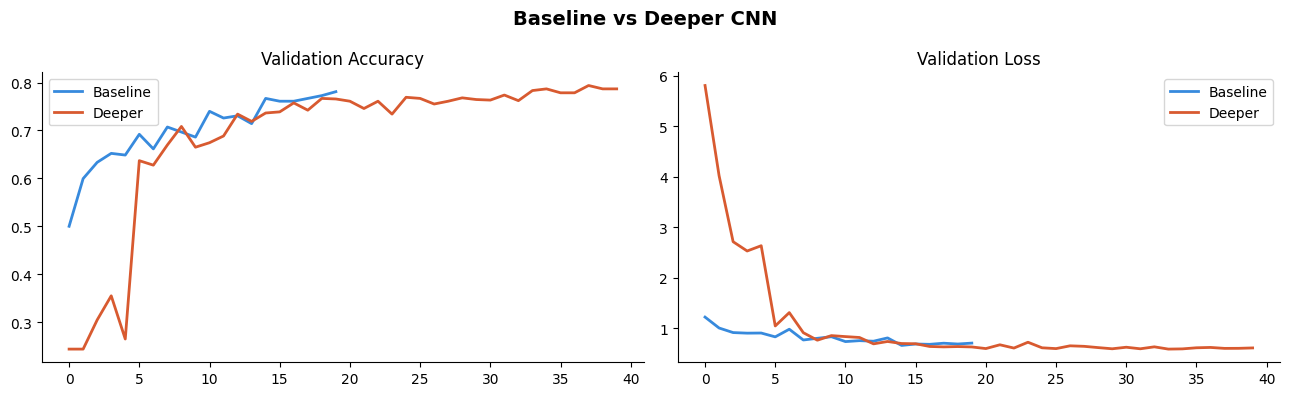

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Baseline vs Deeper CNN', fontsize=14, fontweight='bold')

ax1.plot(history_baseline.history['val_accuracy'], label='Baseline', color='#378ADD', linewidth=2)
ax1.plot(history_deeper.history['val_accuracy'],   label='Deeper',   color='#D85A30', linewidth=2)
ax1.set_title('Validation Accuracy')
ax1.legend()
ax1.spines[['top','right']].set_visible(False)

ax2.plot(history_baseline.history['val_loss'], label='Baseline', color='#378ADD', linewidth=2)
ax2.plot(history_deeper.history['val_loss'],   label='Deeper',   color='#D85A30', linewidth=2)
ax2.set_title('Validation Loss')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('baseline_vs_deeper.png', dpi=150)
plt.show()

---
## Step 6 — Experimentation & Comparative Analysis

In [ ]:
comparison = pd.DataFrame({
    'Metric'   : ['Accuracy','Precision','Recall','F1-Score','Train Time (s)'],
    'Baseline' : [
        f"{baseline_metrics['accuracy']:.4f}",
        f"{baseline_metrics['precision']:.4f}",
        f"{baseline_metrics['recall']:.4f}",
        f"{baseline_metrics['f1']:.4f}",
        f"{baseline_time:.1f}"
    ],
    'Deeper'   : [
        f"{deeper_metrics['accuracy']:.4f}",
        f"{deeper_metrics['precision']:.4f}",
        f"{deeper_metrics['recall']:.4f}",
        f"{deeper_metrics['f1']:.4f}",
        f"{deeper_time:.1f}"
    ]
})
print(comparison.to_string(index=False))

        Metric Baseline Deeper
      Accuracy   0.7670 0.7834
     Precision   0.7750 0.7892
        Recall   0.7670 0.7834
      F1-Score   0.7682 0.7833
Train Time (s)    510.5 1150.7


In [ ]:
model_sgd = build_deeper_cnn()
model_sgd.compile(
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training deeper model with SGD...")
history_sgd = model_sgd.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=7,
                             restore_best_weights=True)],
    verbose=1
)

Training deeper model with SGD...
Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 53s 371ms/step - accuracy: 0.3424 - loss: 1.9790 - val_accuracy: 0.2939 - val_loss: 3.3065
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 37s 348ms/step - accuracy: 0.4265 - loss: 1.5970 - val_accuracy: 0.4930 - val_loss: 1.4167
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 31s 251ms/step - accuracy: 0.4686 - loss: 1.5011 - val_accuracy: 0.5281 - val_loss: 1.2172
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 25s 237ms/step - accuracy: 0.4823 - loss: 1.4431 - val_accuracy: 0.5656 - val_loss: 1.0934
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 249ms/step - accuracy: 0.5215 - loss: 1.2923 - val_accuracy: 0.5703 - val_loss: 1.1081
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 254ms/step - accuracy: 0.5402 - loss: 1.2147 - val_accuracy: 0.5738 - val_loss: 1.1886
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 247ms/step - accuracy: 0.5410 - loss: 1.2040 - val_accuracy: 0.5222 - val_loss: 1.1734
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 248ms

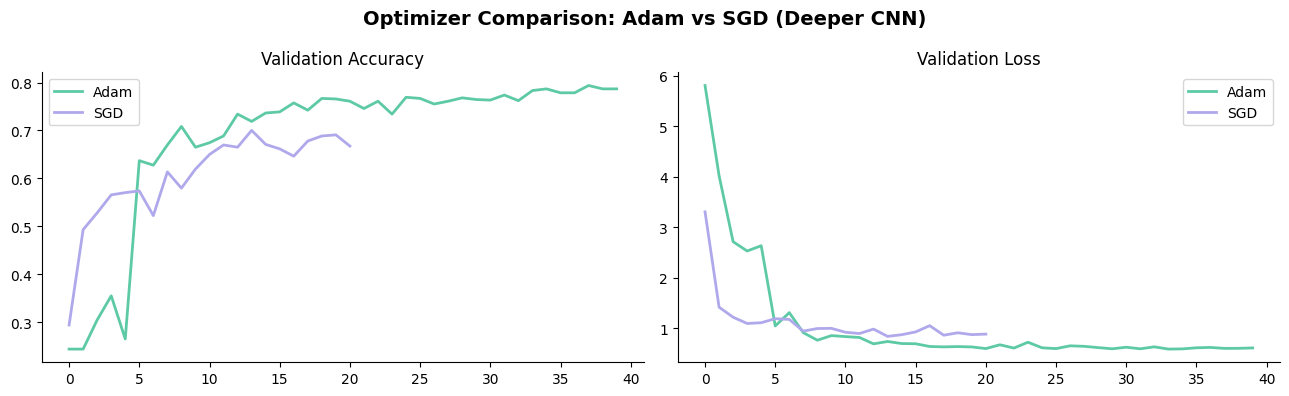


── Deeper CNN SGD ──
Accuracy : 0.7002
Precision: 0.7176
Recall   : 0.7002
F1-Score : 0.6973

Classification Report:

              precision    recall  f1-score   support

       daisy       0.91      0.56      0.70       151
   dandelion       0.64      0.83      0.72       208
        rose       0.65      0.55      0.60       155
   sunflower       0.73      0.81      0.77       145
       tulip       0.69      0.70      0.70       195

    accuracy                           0.70       854
   macro avg       0.73      0.69      0.70       854
weighted avg       0.72      0.70      0.70       854



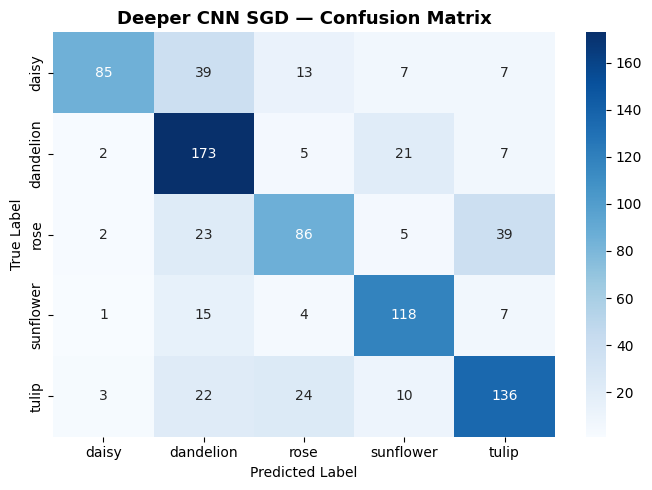

In [ ]:
# SGD vs Adam
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('Optimizer Comparison: Adam vs SGD (Deeper CNN)', fontsize=14, fontweight='bold')

ax1.plot(history_deeper.history['val_accuracy'], label='Adam', linewidth=2)
ax1.plot(history_sgd.history['val_accuracy'],    label='SGD, linewidth=2)
ax1.set_title('Validation Accuracy')
ax1.legend()
ax1.spines[['top','right']].set_visible(False)

ax2.plot(history_deeper.history['val_loss'], label='Adam', linewidth=2)
ax2.plot(history_sgd.history['val_loss'],    label='SGD',  linewidth=2)
ax2.set_title('Validation Loss')
ax2.legend()
ax2.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig('optimizer_comparison.png', dpi=150)
plt.show()

sgd_metrics = evaluate_model(model_sgd, val_gen, 'Deeper CNN SGD')

Training ablation model (no dropout)...
Epoch 1/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 44s 307ms/step - accuracy: 0.4563 - loss: 1.4894 - val_accuracy: 0.2436 - val_loss: 3.5407
Epoch 2/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 252ms/step - accuracy: 0.5822 - loss: 1.0898 - val_accuracy: 0.2436 - val_loss: 3.5258
Epoch 3/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 26s 246ms/step - accuracy: 0.6275 - loss: 0.9904 - val_accuracy: 0.2611 - val_loss: 4.9822
Epoch 4/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 40s 377ms/step - accuracy: 0.6608 - loss: 0.8811 - val_accuracy: 0.4192 - val_loss: 1.9419
Epoch 5/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 30s 280ms/step - accuracy: 0.6886 - loss: 0.8019 - val_accuracy: 0.6112 - val_loss: 1.0854
Epoch 6/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 253ms/step - accuracy: 0.7090 - loss: 0.7645 - val_accuracy: 0.6780 - val_loss: 0.8832
Epoch 7/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 27s 249ms/step - accuracy: 0.7157 - loss: 0.7441 - val_accuracy: 0.6546 - val_loss: 1.1192
Epoch 8/30
107/107 ━━━━━━━━━━━━━━━━━━━━ 28s

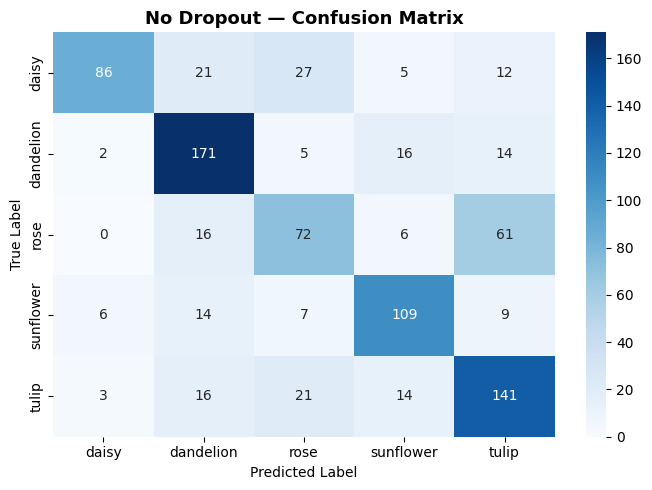


── Ablation Study Result ──
With Dropout    F1: 0.7833
Without Dropout F1: 0.6750


In [ ]:
def build_no_dropout_cnn():
    model = Sequential([
        Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(128,128,3)),
        BatchNormalization(),
        Conv2D(32, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3,3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2,2)),

        Flatten(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dense(256, activation='relu'),
        Dense(5, activation='softmax')
    ], name='No_Dropout')
    return model

model_ablation = build_no_dropout_cnn()
model_ablation.compile(
    optimizer=Adam(0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("Training ablation model (no dropout)...")
history_ablation = model_ablation.fit(
    train_gen,
    epochs=30,
    validation_data=val_gen,
    callbacks=[EarlyStopping(monitor='val_loss', patience=5,
                             restore_best_weights=True)],
    verbose=1
)

ablation_metrics = evaluate_model(model_ablation, val_gen, 'No Dropout')

print("\n── Ablation Study Result ──")
print(f"With Dropout    F1: {deeper_metrics['f1']:.4f}")
print(f"Without Dropout F1: {ablation_metrics['f1']:.4f}")


PART A — FINAL COMPARISON 
               Accuracy  Precision  Recall  F1-Score
Model                                               
Baseline CNN     0.7670     0.7750  0.7670    0.7682
Deeper (Adam)    0.7834     0.7892  0.7834    0.7833
Deeper (SGD)     0.7002     0.7176  0.7002    0.6973
No Dropout       0.6780     0.6900  0.6780    0.6750


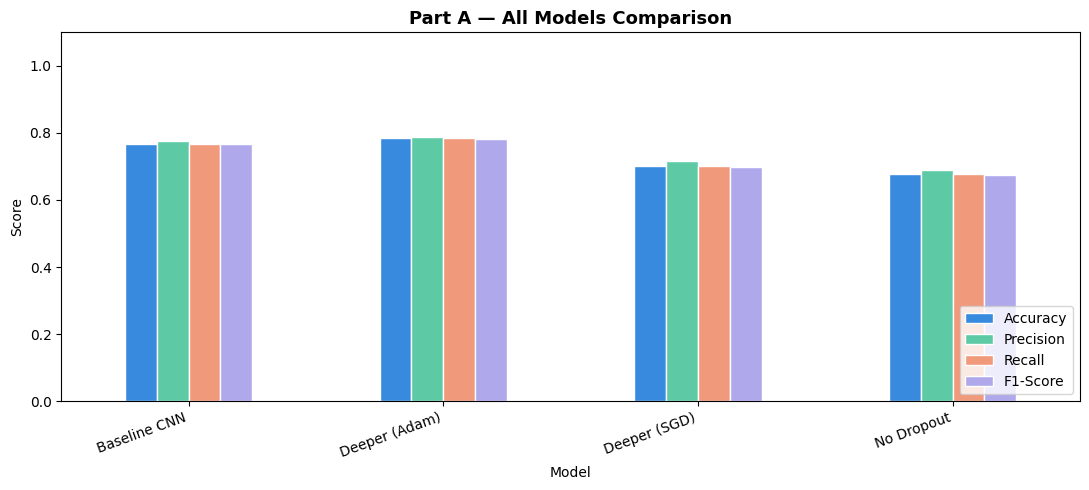

In [ ]:
final = pd.DataFrame({
    'Model'     : ['Baseline CNN', 'Deeper (Adam)', 'Deeper (SGD)', 'No Dropout'],
    'Accuracy'  : [baseline_metrics['accuracy'], deeper_metrics['accuracy'],
                   sgd_metrics['accuracy'],       ablation_metrics['accuracy']],
    'Precision' : [baseline_metrics['precision'], deeper_metrics['precision'],
                   sgd_metrics['precision'],       ablation_metrics['precision']],
    'Recall'    : [baseline_metrics['recall'],    deeper_metrics['recall'],
                   sgd_metrics['recall'],          ablation_metrics['recall']],
    'F1-Score'  : [baseline_metrics['f1'],        deeper_metrics['f1'],
                   sgd_metrics['f1'],              ablation_metrics['f1']]
}).set_index('Model').round(4)

print("Comparison")
print(final.to_string())

final.plot(kind='bar', figsize=(11, 5))
plt.title('All Models Comparison', fontsize=13, fontweight='bold')
plt.ylabel('Score')
plt.ylim(0, 1.1)
plt.xticks(rotation=20, ha='right')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('partA_final_comparison.png', dpi=150)
plt.show()

In [ ]:
# 6e. Training time summary
print("Training Time Summary ")
print(f"  Baseline CNN : {baseline_time:.1f}s  ({baseline_time/60:.1f} min)")
print(f"  Deeper CNN   : {deeper_time:.1f}s  ({deeper_time/60:.1f} min)")
print(f"\n  Hardware: Google Colab T4 GPU")

Training Time Summary 
  Baseline CNN : 510.5s  (8.5 min)
  Deeper CNN   : 1150.7s  (19.2 min)

  Hardware: Google Colab T4 GPU


# Transfer Learning

In [ ]:
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

tl_train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    width_shift_range=0.15,
    height_shift_range=0.15,
    shear_range=0.1,
    zoom_range=0.15,
    horizontal_flip=True,
    fill_mode='nearest',
    validation_split=0.2
)

tl_val_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    validation_split=0.2
)

tl_train_gen = tl_train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

tl_val_gen = tl_val_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

class_names_tl = list(tl_train_gen.class_indices.keys())
print("Train samples:", tl_train_gen.samples)
print("Val   samples:", tl_val_gen.samples)
print("Classes      :", class_names_tl)

Found 3423 images belonging to 5 classes.
Found 854 images belonging to 5 classes.
Train samples: 3423
Val   samples: 854
Classes      : ['daisy', 'dandelion', 'rose', 'sunflower', 'tulip']


#Load MobileNetV2

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
base_model = MobileNetV2(
    weights='imagenet',
    include_top=False,
    input_shape=(224, 224, 3)
)

# Freeze all base layers
base_model.trainable = False

print(f"Total layers in MobileNetV2 : {len(base_model.layers)}")
print(f"Base model output shape     : {base_model.output_shape}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Total layers in MobileNetV2 : 154
Base model output shape     : (None, 7, 7, 1280)


In [ ]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.4)(x)                    # regularisation
output = Dense(NUM_CLASSES, activation='softmax')(x)
tl_model = Model(inputs=base_model.input, outputs=output, name='MobileNetV2_Flowers')

tl_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

tl_model.summary()

Model: "MobileNetV2_Flowers"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_5[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,587,205 (9.87 MB)

 Trainable params: 329,221 (1.26 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

#Phase 1: Feature Extraction

In [ ]:

print("1: Training only  classification head")
print(f"Trainable params: {sum([tf.size(w).numpy() for w in tl_model.trainable_weights]):,}")
print(f"Frozen   params : {sum([tf.size(w).numpy() for w in tl_model.non_trainable_weights]):,}")

Phase 1: Training only the classification head...
Trainable params: 329,221
Frozen   params : 2,257,984


In [ ]:
callbacks_phase1 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

start = time.time()

history_phase1 = tl_model.fit(
    tl_train_gen,
    epochs=15,
    validation_data=tl_val_gen,
    callbacks=callbacks_phase1,
    verbose=1
)

phase1_time = time.time() - start
print(f"\nPhase 1 training time: {phase1_time:.1f}s  ({phase1_time/60:.1f} min)")

Epoch 1/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 123s 880ms/step - accuracy: 0.7625 - loss: 0.6556 - val_accuracy: 0.8852 - val_loss: 0.3386 - learning_rate: 0.0010
Epoch 2/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 60s 554ms/step - accuracy: 0.8434 - loss: 0.4283 - val_accuracy: 0.8689 - val_loss: 0.3505 - learning_rate: 0.0010
Epoch 3/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 63s 585ms/step - accuracy: 0.8700 - loss: 0.3497 - val_accuracy: 0.8841 - val_loss: 0.3283 - learning_rate: 0.0010
Epoch 4/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 53s 492ms/step - accuracy: 0.8846 - loss: 0.3074 - val_accuracy: 0.8923 - val_loss: 0.3248 - learning_rate: 0.0010
Epoch 5/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 56s 525ms/step - accuracy: 0.8937 - loss: 0.3005 - val_accuracy: 0.8923 - val_loss: 0.3024 - learning_rate: 0.0010
Epoch 6/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 55s 516ms/step - accuracy: 0.9045 - loss: 0.2748 - val_accuracy: 0.9005 - val_loss: 0.3159 - learning_rate: 0.0010
Epoch 7/15
107/107 ━━━━━━━━━━━━━━━━━━━━ 55s 513ms/step - accuracy: 0.

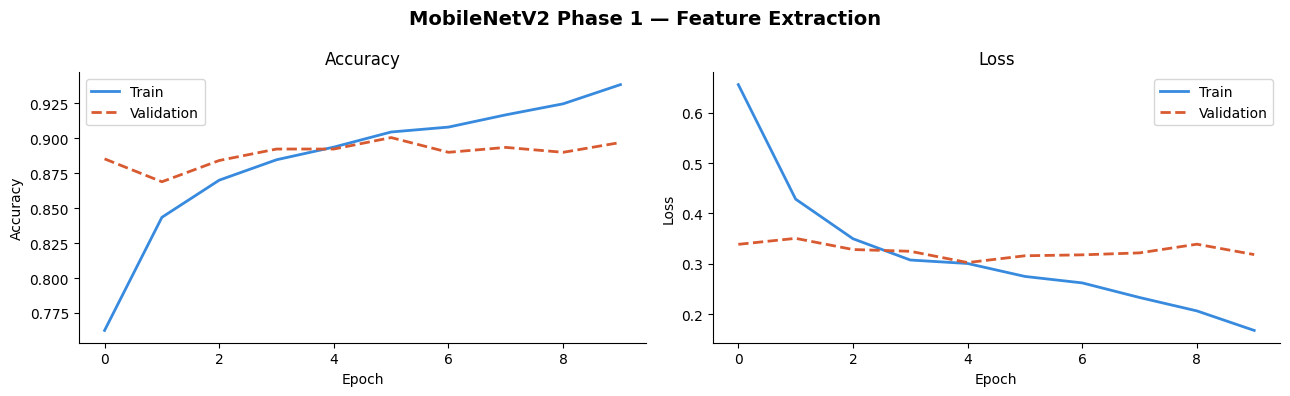

In [ ]:
# Phase 1 training curves
plot_history(history_phase1, 'MobileNetV2 Phase 1 — Feature Extraction', 'tl_phase1_history.png')

#Phase 2: Fine-Tuning (Unfreeze Top Layers)

In [ ]:
# Phase 2 — unfreeze the last 30 layers of MobileNetV2
# Use a very small learning rate to avoid destroying pre-trained weights

base_model.trainable = True

# Keep early layers frozen, only unfreeze last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

unfrozen = sum(1 for l in base_model.layers if l.trainable)
print(f"Layers unfrozen : {unfrozen}")
print(f"Layers frozen   : {len(base_model.layers) - unfrozen}")

# Recompile with much lower learning rate
tl_model.compile(
    optimizer=Adam(learning_rate=1e-5),   # 100x smaller than Phase 1
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print("\nRecompiled with lr=1e-5 for fine-tuning")

Layers unfrozen : 30
Layers frozen   : 124

Recompiled with lr=1e-5 for fine-tuning


In [ ]:
callbacks_phase2 = [
    EarlyStopping(monitor='val_loss', patience=5,
                  restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                      patience=3, verbose=1)
]

start = time.time()

history_phase2 = tl_model.fit(
    tl_train_gen,
    epochs=20,
    validation_data=tl_val_gen,
    callbacks=callbacks_phase2,
    verbose=1
)

phase2_time = time.time() - start
print(f"\nPhase 2 training time: {phase2_time:.1f}s  ({phase2_time/60:.1f} min)")

Epoch 1/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 118s 874ms/step - accuracy: 0.8425 - loss: 0.4487 - val_accuracy: 0.9005 - val_loss: 0.3000 - learning_rate: 1.0000e-05
Epoch 2/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 75s 705ms/step - accuracy: 0.8720 - loss: 0.3562 - val_accuracy: 0.9052 - val_loss: 0.2987 - learning_rate: 1.0000e-05
Epoch 3/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 70s 648ms/step - accuracy: 0.8761 - loss: 0.3368 - val_accuracy: 0.9040 - val_loss: 0.3066 - learning_rate: 1.0000e-05
Epoch 4/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 53s 495ms/step - accuracy: 0.8983 - loss: 0.2833 - val_accuracy: 0.9087 - val_loss: 0.2876 - learning_rate: 1.0000e-05
Epoch 5/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 56s 519ms/step - accuracy: 0.9010 - loss: 0.2713 - val_accuracy: 0.9075 - val_loss: 0.2878 - learning_rate: 1.0000e-05
Epoch 6/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 56s 523ms/step - accuracy: 0.9167 - loss: 0.2516 - val_accuracy: 0.9075 - val_loss: 0.2769 - learning_rate: 1.0000e-05
Epoch 7/20
107/107 ━━━━━━━━━━━━━━━━━━━━ 54s 5

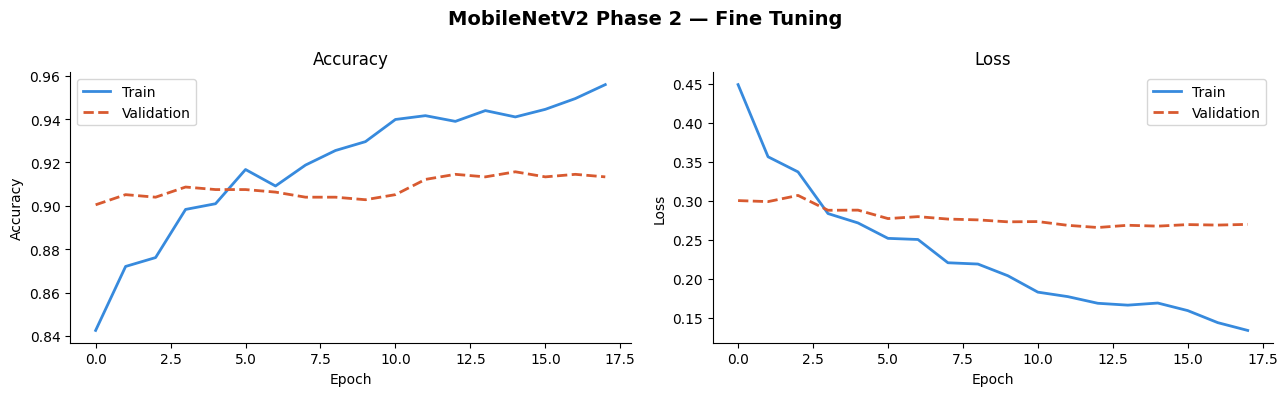

In [ ]:
#  training curves
plot_history(history_phase2, 'MobileNetV2 Phase 2 — Fine Tuning', 'tl_phase2_history.png')

#Evaluate Fine-Tuned Model


── MobileNetV2 Fine Tuned ──
Accuracy : 0.9145
Precision: 0.9155
Recall   : 0.9145
F1-Score : 0.9146

Classification Report:

              precision    recall  f1-score   support

       daisy       0.91      0.93      0.92       151
   dandelion       0.94      0.90      0.92       208
        rose       0.93      0.90      0.91       155
   sunflower       0.87      0.94      0.91       145
       tulip       0.91      0.91      0.91       195

    accuracy                           0.91       854
   macro avg       0.91      0.92      0.91       854
weighted avg       0.92      0.91      0.91       854



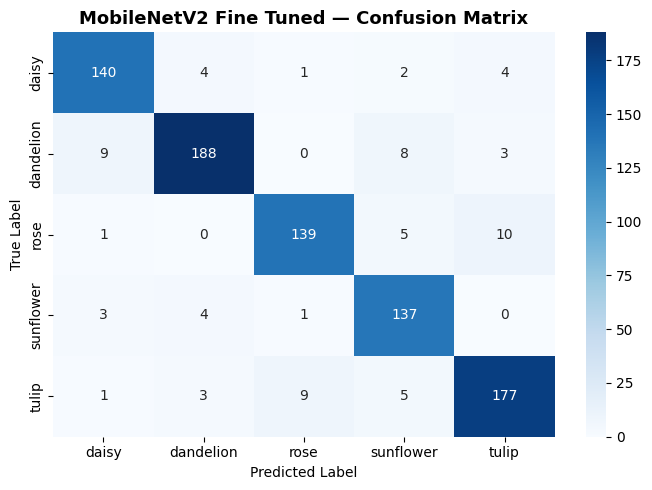

In [ ]:
tl_metrics = evaluate_model(tl_model, tl_val_gen, 'MobileNetV2 Fine Tuned')

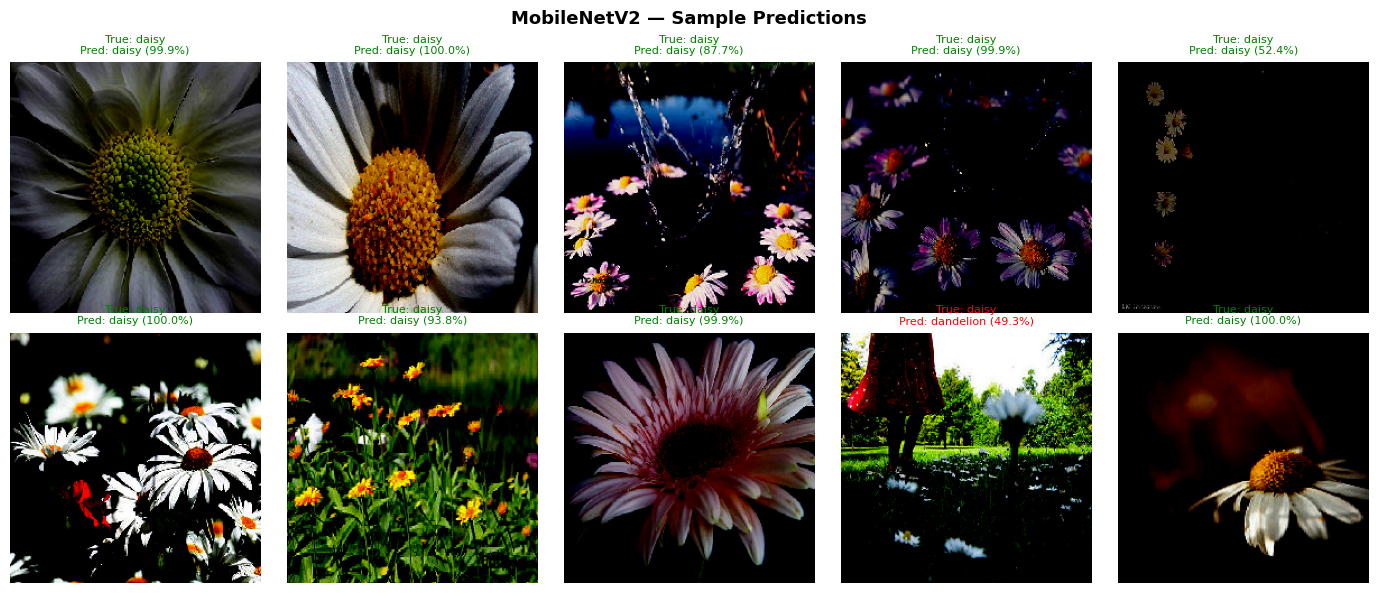

In [ ]:
show_predictions(tl_model, tl_val_gen, 'MobileNetV2 — Sample Predictions')

# Predict on Test Images

In [ ]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

test_images = [
    f for f in os.listdir(TEST_DIR)
    if f.lower().endswith(('.jpg', '.jpeg', '.png'))
]

print(f"Test images found: {len(test_images)}")

Test images found: 5


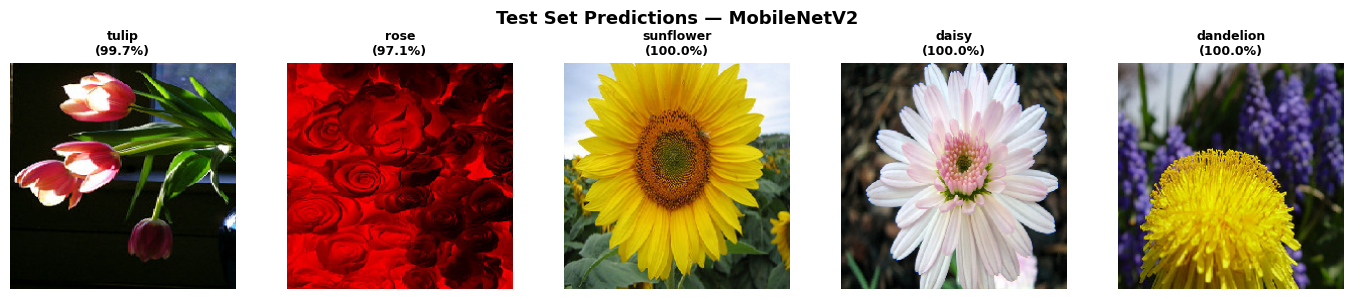

In [ ]:
# Predict test images
cols = 5
rows = max(1, -(-len(test_images) // cols))

fig, axes = plt.subplots(rows, cols, figsize=(14, rows * 3))
axes = axes.flat if rows > 1 else axes
fig.suptitle('Test Set Predictions — MobileNetV2', fontsize=13, fontweight='bold')

for i, (ax, fname) in enumerate(zip(axes, test_images)):
    img_path = os.path.join(TEST_DIR, fname)
    img      = load_img(img_path, target_size=(224, 224))
    arr      = img_to_array(img)
    inp      = preprocess_input(np.expand_dims(arr, axis=0))

    pred     = tl_model.predict(inp, verbose=0)[0]
    pred_cls = class_names_tl[np.argmax(pred)]
    conf     = np.max(pred) * 100

    ax.imshow(img)
    ax.set_title(f'{pred_cls}\n({conf:.1f}%)', fontsize=9, fontweight='bold')
    ax.axis('off')

for ax in list(axes)[len(test_images):]:
    ax.axis('off')

plt.tight_layout()
plt.savefig('test_predictions.png', dpi=150)
plt.show()

#Final Comparison: All Models

In [ ]:
final = pd.DataFrame({
    'Model'     : [
        'Baseline CNN',
        'Deeper CNN (Adam)',
        'Deeper CNN (SGD)',
        'No Dropout (Ablation)',
        'MobileNetV2 (Fine-Tuned)'
    ],
    'Accuracy'  : [
        baseline_metrics['accuracy'],
        deeper_metrics['accuracy'],
        sgd_metrics['accuracy'],
        ablation_metrics['accuracy'],
        tl_metrics['accuracy']
    ],
    'Precision' : [
        baseline_metrics['precision'],
        deeper_metrics['precision'],
        sgd_metrics['precision'],
        ablation_metrics['precision'],
        tl_metrics['precision']
    ],
    'Recall'    : [
        baseline_metrics['recall'],
        deeper_metrics['recall'],
        sgd_metrics['recall'],
        ablation_metrics['recall'],
        tl_metrics['recall']
    ],
    'F1-Score'  : [
        baseline_metrics['f1'],
        deeper_metrics['f1'],
        sgd_metrics['f1'],
        ablation_metrics['f1'],
        tl_metrics['f1']
    ]
}).set_index('Model').round(4)

print("FINAL COMPARISON — ALL MODELS")
print(final.to_string())

FINAL COMPARISON — ALL MODELS
                          Accuracy  Precision  Recall  F1-Score
Model                                                          
Baseline CNN                0.7670     0.7750  0.7670    0.7682
Deeper CNN (Adam)           0.7834     0.7892  0.7834    0.7833
Deeper CNN (SGD)            0.7002     0.7176  0.7002    0.6973
No Dropout (Ablation)       0.6780     0.6900  0.6780    0.6750
MobileNetV2 (Fine-Tuned)    0.9145     0.9155  0.9145    0.9146


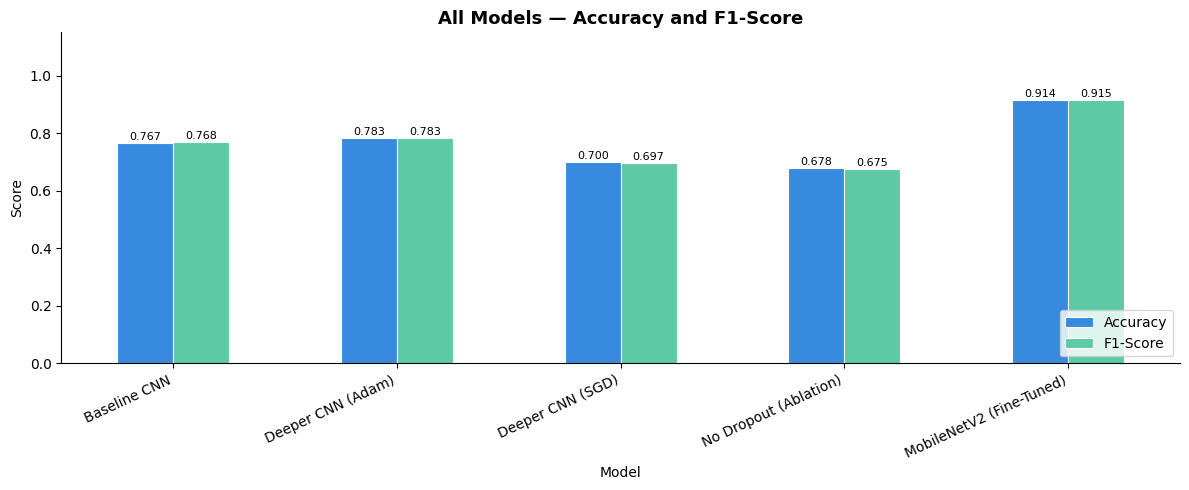

In [ ]:
# Bar chart
ax = final[['Accuracy', 'F1-Score']].plot(
    kind='bar',
    figsize=(12, 5),
    color=['#378ADD', '#5DCAA5'],
    edgecolor='white',
    linewidth=0.8
)
ax.set_title('Accuracy and F1-Score', fontsize=13, fontweight='bold')
ax.set_ylabel('Score')
ax.set_ylim(0, 1.15)
ax.legend(loc='lower right')
ax.set_xticklabels(ax.get_xticklabels(), rotation=25, ha='right')
ax.spines[['top', 'right']].set_visible(False)

for p in ax.patches:
    ax.annotate(f'{p.get_height():.3f}',
                (p.get_x() + p.get_width()/2, p.get_height() + 0.01),
                ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('final_all_models.png', dpi=150)
plt.show()

In [ ]:
print("TRAINING TIME SUMMARY")
print(f"  Baseline CNN       : {baseline_time:.1f}s  ({baseline_time/60:.1f} min)")
print(f"  Deeper CNN         : {deeper_time:.1f}s  ({deeper_time/60:.1f} min)")
print(f"  MobileNetV2 Phase1 : {phase1_time:.1f}s  ({phase1_time/60:.1f} min)")
print(f"  MobileNetV2 Phase2 : {phase2_time:.1f}s  ({phase2_time/60:.1f} min)")
total_tl = phase1_time + phase2_time
print(f"  MobileNetV2 Total  : {total_tl:.1f}s  ({total_tl/60:.1f} min)")
print()
print("  Hardware: Google Colab T4 GPU")

TRAINING TIME SUMMARY
  Baseline CNN       : 510.5s  (8.5 min)
  Deeper CNN         : 1150.7s  (19.2 min)
  MobileNetV2 Phase1 : 660.8s  (11.0 min)
  MobileNetV2 Phase2 : 1081.4s  (18.0 min)
  MobileNetV2 Total  : 1742.2s  (29.0 min)

  Hardware: Google Colab T4 GPU
